# IEEE-CID Fraud Detection — Data Preprocessing Pipeline
This notebook covers the full preprocessing pipeline for the IEEE-CID fraud detection dataset, designed for a deep learning (neural network) model.

**Steps covered:**
1. Load & Merge transaction + identity datasets
2. Define column groups
3. Feature engineering (time-based, aggregation, interaction)
4. Clean data (impute, outlier capping)
5. Train / Val / Test split (80 / 5 / 15) with stratification
6. Encode categorical features
7. Scale numerical features
8. Save outputs

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle #serializing python objects
import os
import matplotlib.pyplot as plt

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Merge
We do a **left join** on `TransactionID` so that all transactions are kept, even if they have no corresponding identity record (most won't).

In [2]:
transaction = pd.read_csv('data/train_transaction.csv')
identity    = pd.read_csv('data/train_identity.csv')

df = transaction.merge(identity, on='TransactionID', how='left')

print(f'Transaction rows : {len(transaction):,}')
print(f'Identity rows    : {len(identity):,}')
print(f'Merged rows      : {len(df):,}')
print(f'Merged columns   : {df.shape[1]}')

df.head()

Transaction rows : 590,540
Identity rows    : 144,233
Merged rows      : 590,540
Merged columns   : 434


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 2. Define Column Groups

In [3]:
target    = 'isFraud'
drop_cols = ['TransactionID']  # ID column, not a feature

# Categorical columns
cat_cols_candidates = [
    'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2',
    'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29',
    'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
    'DeviceType', 'DeviceInfo'
]
cat_cols = [c for c in cat_cols_candidates if c in df.columns]

# Numerical: everything else except target, drops, and categoricals
num_cols = [
    c for c in df.columns
    if c not in ([target] + drop_cols + cat_cols)
]

print(f'Categorical columns : {len(cat_cols)}')
print(f'Numerical columns   : {len(num_cols)}')
print(f'Target              : {target}')

Categorical columns : 37
Numerical columns   : 395
Target              : isFraud


## 2.EDA

In [4]:
#List of names of all the columns in the dataset
print('All columns in the dataset:')
print(df.columns.tolist()) 

All columns in the dataset:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V

In [5]:
# Percentage of entire dataset that is fraudulent
fraud_percentage = df['isFraud'].mean() * 100
print(f'Percentage of fraudulent transactions: {fraud_percentage:.4f}%')

#Number of Fraudulent and Non-Fraudulent transactions
fraud_counts = df['isFraud'].value_counts()
print('Number of transactions by class:')
print(fraud_counts) 

Percentage of fraudulent transactions: 3.4990%
Number of transactions by class:
isFraud
0    569877
1     20663
Name: count, dtype: int64


In [6]:
missing_values = ['', 'NA', 'NaN', 'None']
df.replace(missing_values, np.nan, inplace=True)
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [7]:
nan_summary = pd.DataFrame({
    'nan_count': df.isnull().sum(),
    'nan_percentage': df.isnull().mean() * 100
})

count_missing = (nan_summary['nan_percentage'] > 75).sum()

nan_summary_sorted = nan_summary.sort_values(by='nan_percentage', ascending=False)

pd.set_option('display.max_rows', None)
print(nan_summary_sorted)   
print(f'Number of columns with more than 70% missing values: {count_missing}')

                nan_count  nan_percentage
id_24              585793       99.196159
id_25              585408       99.130965
id_07              585385       99.127070
id_08              585385       99.127070
id_21              585381       99.126393
id_26              585377       99.125715
id_27              585371       99.124699
id_23              585371       99.124699
id_22              585371       99.124699
dist2              552913       93.628374
D7                 551623       93.409930
id_18              545427       92.360721
D13                528588       89.509263
D14                528353       89.469469
D12                525823       89.041047
id_03              524216       88.768923
id_04              524216       88.768923
D6                 517353       87.606767
id_33              517251       87.589494
id_10              515614       87.312290
id_09              515614       87.312290
D9                 515614       87.312290
D8                 515614       87

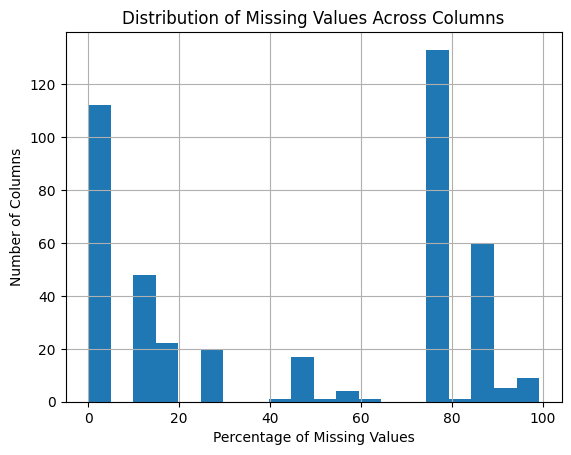

In [8]:
plt.figure()
plt.hist(nan_summary['nan_percentage'], bins=20)
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Number of Columns')
plt.title('Distribution of Missing Values Across Columns')
plt.grid()
plt.show()

In [9]:
tbd_columns = nan_summary[nan_summary['nan_percentage'] > 75].index.tolist()
print('Columns with more than 75% missing values:')
print(tbd_columns)

#Categorical columns among those with >75% missing values
categorical_tbd_columns = df[tbd_columns].select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns among those with >75% missing values:')
print(categorical_tbd_columns)

# keep only numeric columns
numeric_tbd_columns = df[tbd_columns].select_dtypes(include='number').columns.tolist()

print('Numeric columns among those with >75% missing values:')
print(numeric_tbd_columns)

correlation_matrix = df[numeric_tbd_columns].corr()
print('Correlation matrix for numeric columns with >75% missing values:')
print(correlation_matrix)

Columns with more than 75% missing values:
['dist2', 'R_emaildomain', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V241', 'V242', 'V243', 'V244', 'V245', 'V246', 'V247', 'V248

## 3. Feature Engineering
Feature engineering is done **before the split** since frequency-based features need global context.

> ⚠️ **Note:** This means frequency features technically include a small amount of val/test information. This is a common pragmatic trade-off in fraud detection. If you want strict no-leakage, move this section to after the split and compute on train only.

Features added:
- **Aggregation**: card frequency, per-card transaction amount stats, deviation from card mean
- **Transaction amount**: log transform, cents (decimal part)
- **Interaction**: card+address frequency, card+email frequency
- **M-column summary**: count of T/F/null across M1–M9

In [10]:
# ── Card frequency features ──────────────────────────────────────────────────
for col in ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']:
    if col in df.columns:
        df[f'{col}_freq'] = df[col].map(df[col].value_counts())

# ── Email domain frequency ───────────────────────────────────────────────────
for col in ['P_emaildomain', 'R_emaildomain']:
    if col in df.columns:
        df[f'{col}_freq'] = df[col].map(df[col].value_counts())

# ── Per-card transaction amount stats ───────────────────────────────────────
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
card_num_cols = ['card1', 'card2', 'card3', 'card5']

for col in card_num_cols:
    if col in df.columns:
        stats = df.groupby(col)['TransactionAmt'].agg(['mean', 'std', 'count'])
        stats.columns = [f'{col}_amt_mean', f'{col}_amt_std', f'{col}_count']
        df = df.merge(stats, on=col, how='left')
        df[f'{col}_amt_diff_from_mean'] = df['TransactionAmt'] - df[f'{col}_amt_mean']
        df[f'{col}_amt_ratio_to_mean'] = df['TransactionAmt'] / (df[f'{col}_amt_mean'] + 1e-9)

# ── Transaction amount features ──────────────────────────────────────────────
df['TransactionAmt_log']   = np.log1p(df['TransactionAmt'])
df['TransactionAmt_cents'] = (df['TransactionAmt'] % 1).round(2)

# ── Interaction features ─────────────────────────────────────────────────────
for col in card_cols:
    if col in df.columns:
        # card + address
        if 'addr1' in df.columns:
            combo = df[col].astype(str) + '_' + df['addr1'].astype(str)
            df[f'{col}_addr1_freq'] = combo.map(combo.value_counts())
        
        # card + email
        if 'P_emaildomain' in df.columns:
            combo = df[col].astype(str) + '_' + df['P_emaildomain'].astype(str)
            df[f'{col}_email_freq'] = combo.map(combo.value_counts())

# ── M-column summary features ────────────────────────────────────────────────
m_cols = [c for c in df.columns if c.startswith('M') and c[1:].isdigit()]
if m_cols:
    df['M_true_count']  = (df[m_cols] == 'T').sum(axis=1)
    df['M_false_count'] = (df[m_cols] == 'F').sum(axis=1)
    df['M_null_count']  = df[m_cols].isnull().sum(axis=1)

print(f'Shape after feature engineering: {df.shape}')

Shape after feature engineering: (590540, 479)


In [11]:
# Refresh column groups after new features were added
cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [
    c for c in df.columns
    if c not in ([target] + drop_cols + cat_cols)
]
print(f'Updated — Categorical: {len(cat_cols)}, Numerical: {len(num_cols)}')

Updated — Categorical: 37, Numerical: 440


In [12]:
# Print all column names
print(df.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

## 4. Clean Data
- Drop columns with **>90% missing values** (common in this dataset's V-columns)
- **Median impute** numerical NaNs — neural networks cannot handle NaN inputs
- Fill categorical NaNs with a dedicated `'missing'` category
- **Winsorise** numerical outliers at 1st/99th percentile — neural networks are sensitive to extreme values

In [13]:
# ── Drop high-missingness columns ────────────────────────────────────────────
missing_rate  = df[num_cols + cat_cols].isnull().mean()
high_missing  = missing_rate[missing_rate > 0.75].index.tolist()

print(f'Dropping {len(high_missing)} columns with >75% missing values')
df.drop(columns=high_missing, inplace=True)
cat_cols = [c for c in cat_cols if c not in high_missing]
num_cols = [c for c in num_cols if c not in high_missing]

# ── Impute numerical columns ─────────────────────────────────────────────────
for col in num_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# ── Impute categorical columns ───────────────────────────────────────────────
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).replace('nan', 'missing')

# ── Winsorise outliers ───────────────────────────────────────────────────────
for col in num_cols:
    if col in df.columns:
        low  = df[col].quantile(0.01)
        high = df[col].quantile(0.99)
        df[col] = df[col].clip(low, high)

# ── Drop ID column ───────────────────────────────────────────────────────────
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(f'Shape after cleaning: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Dropping 209 columns with >75% missing values
Shape after cleaning: (590540, 269)
Remaining nulls: 0


## 5. Train / Val / Test Split (80 / 5 / 15)
We split **before** encoding and scaling to prevent data leakage. Stratification ensures all three splits maintain the same ~3.5% fraud rate.

In [14]:
# Step 1: split off 15% test
train_val, test = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df[target]
)

# Step 2: split remaining 85% into 80% train and 5% val
# 5% of total = 5/85 ≈ 0.0588 of train_val
train, val = train_test_split(
    train_val, test_size=0.0588, random_state=42, stratify=train_val[target]
)

print(f'Train      : {len(train):,} rows ({len(train)/len(df):.1%}) | fraud rate: {train[target].mean():.3%}')
print(f'Validation : {len(val):,} rows ({len(val)/len(df):.1%})  | fraud rate: {val[target].mean():.3%}')
print(f'Test       : {len(test):,} rows ({len(test)/len(df):.1%}) | fraud rate: {test[target].mean():.3%}')

Train      : 472,443 rows (80.0%) | fraud rate: 3.499%
Validation : 29,516 rows (5.0%)  | fraud rate: 3.500%
Test       : 88,581 rows (15.0%) | fraud rate: 3.498%


## 6. Encode Categorical Features
We **label encode** categoricals to integers. For a neural network, these integer codes will typically be passed into `nn.Embedding` layers rather than one-hot encoded — this keeps dimensionality manageable for high-cardinality columns like `card1` or `DeviceInfo`.

Encoders are **fit on train only**, then applied to val and test. Unseen categories in val/test are mapped to an out-of-vocabulary index.

In [ ]:
encoders = {}

for col in cat_cols:
    if col not in train.columns:
        continue

    le = LabelEncoder()
    le.fit(train[col])
    classes = list(le.classes_)

    def safe_transform(series, le=le, classes=classes):
        """Map unseen categories to len(classes) (out-of-vocabulary index)."""
        return series.map(lambda x: le.transform([x])[0] if x in classes else len(classes))

    train[col] = safe_transform(train[col])
    val[col]   = safe_transform(val[col])
    test[col]  = safe_transform(test[col])
    encoders[col] = le

print(f'Encoded {len(encoders)} categorical columns.')

# Vocabulary sizes — useful for defining Embedding layers in your model
vocab_sizes = {col: len(le.classes_) + 1 for col, le in encoders.items()}  # +1 for OOV
print('\nVocabulary sizes (for Embedding layers):')
for col, size in vocab_sizes.items():
    print(f'  {col}: {size}')

## 7. Scale Numerical Features
`StandardScaler` is fit on **train only** and applied to val and test. This is essential for neural networks to converge properly.

In [ ]:
num_cols_to_scale = [c for c in num_cols if c in train.columns and c != target]

scaler = StandardScaler()
train[num_cols_to_scale] = scaler.fit_transform(train[num_cols_to_scale])
val[num_cols_to_scale]   = scaler.transform(val[num_cols_to_scale])
test[num_cols_to_scale]  = scaler.transform(test[num_cols_to_scale])

print(f'Scaled {len(num_cols_to_scale)} numerical columns.')

## 8. Final Check

In [ ]:
print('=== Final Dataset Summary ===')
print(f'Train      : {train.shape}  | nulls: {train.isnull().sum().sum()}')
print(f'Validation : {val.shape}    | nulls: {val.isnull().sum().sum()}')
print(f'Test       : {test.shape}   | nulls: {test.isnull().sum().sum()}')
print(f'\nFraud rate — Train: {train[target].mean():.3%} | Val: {val[target].mean():.3%} | Test: {test[target].mean():.3%}')
print(f'\nNumerical features : {len(num_cols_to_scale)}')
print(f'Categorical features: {len(encoders)}')

train.head()

## 9. Save Outputs

In [ ]:
os.makedirs('preprocessed', exist_ok=True)

train.to_csv('preprocessed/train.csv', index=False)
val.to_csv('preprocessed/val.csv',     index=False)
test.to_csv('preprocessed/test.csv',   index=False)

with open('preprocessed/scaler.pkl',   'wb') as f: pickle.dump(scaler,      f)
with open('preprocessed/encoders.pkl', 'wb') as f: pickle.dump(encoders,    f)

metadata = {
    'cat_cols'    : cat_cols,
    'num_cols'    : num_cols_to_scale,
    'vocab_sizes' : vocab_sizes,
    'target'      : target
}
with open('preprocessed/column_metadata.pkl', 'wb') as f: pickle.dump(metadata, f)

print('Saved to ./preprocessed/')
print('  train.csv, val.csv, test.csv')
print('  scaler.pkl, encoders.pkl, column_metadata.pkl')